# 📊 Descriptive Statistics Exercise
## World Happiness Report 2026
---

> **Petunjuk Umum:**  
> - Isi setiap cell kode di bawah ini.  
> - Tulis interpretasi Anda di cell Markdown yang telah disediakan (bertanda ✏️).  
> - Jangan hapus cell yang sudah ada — tambahkan cell baru jika diperlukan.  
> - Pastikan semua cell sudah dijalankan sebelum mengumpulkan.

---
## ⚙️ Import Library

In [133]:
# Import semua library yang dibutuhkan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats

# Plot settings
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('Blues_d')

print('Library berhasil di-import')

Library berhasil di-import


---
# Bagian 1 – Data Preparation & Eksplorasi Awal
Sebelum melakukan analisis, kita perlu memahami struktur dataset dan memastikan data siap digunakan.

## Task 1.1 – Load & Inspect Dataset

**a.** Download *Data for Table 2.1* dari [https://www.worldhappiness.report/data-sharing/](https://www.worldhappiness.report/data-sharing/)
lalu load ke dalam DataFrame bernama `df_whr`.

In [134]:
# a. Load dataset ke dalam df_whr
# Ganti path di bawah sesuai lokasi file Anda
df_whr = pd.read_excel('WHR26_Data_Figure_2.1.xlsx')
df_whr = df_whr.rename(columns={
    'Year': 'year',
    'Life evaluation (3-year average)': 'Life Ladder',
    'Explained by: Log GDP per capita': 'Log GDP per capita',
    'Explained by: Social support': 'Social support',
    'Explained by: Healthy life expectancy': 'Healthy life expectancy at birth',
    'Explained by: Freedom to make life choices': 'Freedom to make life choices',
    'Explained by: Generosity': 'Generosity',
    'Explained by: Perceptions of corruption': 'Perceptions of corruption',
})
print(f'Shape dataset: {df_whr.shape}')

Shape dataset: (2116, 13)


**b.** Tampilkan 5 baris pertama dan 5 baris terakhir dataset.

In [135]:
# b. Tampilkan 5 baris pertama
display(df_whr.head())

# 5 baris terakhir
display(df_whr.tail())

,year,Rank,Country name,Life Ladder,Lower whisker,Upper whisker,Log GDP per capita,Social support,Healthy life expectancy at birth,Freedom to make life choices,Generosity,Perceptions of corruption,Dystopia + residual
0,2025,1,Finland,7.764,7.690,7.837,1.915,1.638,0.939,1.105,0.093,0.491,1.582
1,2025,2,Iceland,7.540,7.449,7.630,1.971,1.720,0.996,1.105,0.187,0.187,1.373
2,2025,3,Denmark,7.539,7.446,7.631,1.986,1.633,0.930,1.081,0.125,0.474,1.310
3,2025,4,Costa Rica,7.439,7.356,7.522,1.697,1.483,0.739,1.101,0.059,0.122,2.236
4,2025,5,Sweden,7.255,7.172,7.337,1.950,1.570,1.027,1.070,0.149,0.447,1.041


,year,Rank,Country name,Life Ladder,Lower whisker,Upper whisker,Log GDP per capita,Social support,Healthy life expectancy at birth,Freedom to make life choices,Generosity,Perceptions of corruption,Dystopia + residual
2111,2011,152,Burundi,3.678,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2112,2011,153,Sierra Leone,3.586,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2113,2011,154,Central African Republic,3.568,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2114,2011,155,Benin,3.493,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2115,2011,156,Togo,3.007,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**c.** Cek dimensi dataset.

In [136]:
# c. Dimensi dataset
print(f'Jumlah baris  : {df_whr.shape[0]}')
print(f'Jumlah kolom  : {df_whr.shape[1]}')

Jumlah baris  : 2116
Jumlah kolom  : 13


**d.** Tampilkan daftar kolom beserta tipe datanya.

In [137]:
# d. Info kolom dan tipe data
df_whr.info()

<class 'pandas.DataFrame'>
RangeIndex: 2116 entries, 0 to 2115
Data columns (total 13 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   year                              2116 non-null   int64  
 1   Rank                              2116 non-null   int64  
 2   Country name                      2116 non-null   str    
 3   Life Ladder                       2116 non-null   float64
 4   Lower whisker                     1022 non-null   float64
 5   Upper whisker                     1022 non-null   float64
 6   Log GDP per capita                1019 non-null   float64
 7   Social support                    1019 non-null   float64
 8   Healthy life expectancy at birth  1016 non-null   float64
 9   Freedom to make life choices      1017 non-null   float64
 10  Generosity                        1019 non-null   float64
 11  Perceptions of corruption         1018 non-null   float64
 12  Dystopia + residu

**e.** Cek missing values — tampilkan jumlah dan persentasenya.

In [138]:
# e. Missing values
missing = pd.DataFrame({
    'Jumlah Missing' : df_whr.isnull().sum(),
    'Persentase (%)'  : (df_whr.isnull().sum() / len(df_whr) * 100).round(2)
})
missing[missing['Jumlah Missing'] > 0]

,Jumlah Missing,Persentase (%)
Lower whisker,1094,51.70
Upper whisker,1094,51.70
Log GDP per capita,1097,51.84
Social support,1097,51.84
Healthy life expectancy at birth,1100,51.98
Freedom to make life choices,1099,51.94
Generosity,1097,51.84
Perceptions of corruption,1098,51.89
Dystopia + residual,1103,52.13


**f.** Buat DataFrame `df_idn` — data Indonesia tahun 2021–2025.

In [139]:
# f. Filter data Indonesia 2006–2023
last5 = [2021, 2022, 2023, 2024, 2025]
df_idn = df_whr[(df_whr['Country name'] == 'Indonesia') & (df_whr['year'].isin(last5))].sort_values('year').reset_index(drop=True)

print(f'Jumlah baris df_idn : {len(df_idn)}')
print(f"Rentang tahun       : {df_idn['year'].min()} - {df_idn['year'].max()}")
display(df_idn)

Jumlah baris df_idn : 5
Rentang tahun       : 2021 - 2025


,year,Rank,Country name,Life Ladder,Lower whisker,Upper whisker,Log GDP per capita,Social support,Healthy life expectancy at birth,Freedom to make life choices,Generosity,Perceptions of corruption,Dystopia + residual
0,2021,87,Indonesia,5.240,5.139,5.341,1.382,0.883,0.539,0.620,0.468,0.047,1.300
1,2022,84,Indonesia,5.277,5.161,5.392,1.384,1.169,0.314,0.663,0.422,0.038,1.288
2,2023,80,Indonesia,5.568,5.466,5.670,1.361,1.184,0.472,0.779,0.399,0.055,1.318
3,2024,83,Indonesia,5.617,5.516,5.717,1.288,1.372,0.454,0.918,0.323,0.044,1.218
4,2025,87,Indonesia,5.617,5.517,5.718,1.512,1.229,0.485,1.043,0.295,0.033,1.020


## Task 1.2 – Klasifikasi Variabel

**a.** Jelaskan perbedaan variabel **Kualitatif** dan **Kuantitatif**,  
beserta sub-kategori masing-masing (Nominal, Ordinal, Diskrit, Kontinu).

✏️ *Jawaban Anda di sini:*

- **Kualitatif** :
  - Nominal  : `Country name` — nama negara.
  - Ordinal  : `Rank`sebagai (peringkat berurutan).
- **Kuantitatif** :
  - Diskrit  : `year`, `Rank`
  - Kontinu  : `Life Ladder`, `Lower whisker`, `Upper whisker`, `Log GDP per capita`, `Social support`, `Healthy life expectancy at birth`, `Freedom to make life choices`, `Generosity`, `Perceptions of corruption`, `Dystopia + residual`


Kualitatif:
Nominal : Country name
Ordinal : Tidak ada
Kuantitatif:
Diskrit : Year, Rank
Kontinu : Life evaluation, Lower whisker, Upper whisker, Log GDP per capita, Social support, Healthy life expectancy, Freedom to make life choices, Generosity, Perceptions of corruption, Dystopia + residual

**b & c.** Klasifikasikan semua kolom `df_idn` ke dalam tabel klasifikasi.

In [140]:
# b & c. Tabel klasifikasi variabel
klasifikasi = pd.DataFrame({
    'nama_kolom': df_idn.columns.tolist(),

    'tipe_variabel': [
        'Kuantitatif - Diskrit',    # Year
        'Kuantitatif - Diskrit',    # Rank
        'Kualitatif - Nominal',     # Country name
        'Kuantitatif - Kontinu',    # Life evaluation
        'Kuantitatif - Kontinu',    # Lower whisker
        'Kuantitatif - Kontinu',    # Upper whisker
        'Kuantitatif - Kontinu',    # Log GDP per capita
        'Kuantitatif - Kontinu',    # Social support
        'Kuantitatif - Kontinu',    # Healthy life expectancy
        'Kuantitatif - Kontinu',    # Freedom
        'Kuantitatif - Kontinu',    # Generosity
        'Kuantitatif - Kontinu',    # Perceptions of corruption
        'Kuantitatif - Kontinu'     # Dystopia + residual
    ],

    'alasan': [
        'Tahun berupa bilangan bulat yang dapat dihitung',
        'Peringkat berupa bilangan bulat yang menunjukkan urutan',
        'Nama negara bersifat kategorik tanpa urutan',
        'Nilai evaluasi kehidupan berupa nilai numerik yang dapat memiliki desimal',
        'Batas bawah dari nilai evaluasi berupa nilai numerik kontinu',
        'Batas atas dari nilai evaluasi berupa nilai numerik kontinu',
        'Nilai GDP per kapita dalam bentuk logaritmik berupa data numerik kontinu',
        'Nilai dukungan sosial berupa data numerik kontinu',
        'Nilai harapan hidup sehat berupa data numerik kontinu',
        'Nilai kebebasan dalam menentukan pilihan hidup berupa data numerik kontinu',
        'Nilai kemurahan hati berupa data numerik kontinu',
        'Nilai persepsi terhadap korupsi berupa data numerik kontinu',
        'Nilai residual dan dystopia berupa data numerik kontinu'
    ]
})

display(klasifikasi)

,nama_kolom,tipe_variabel,alasan
0,year,Kuantitatif - Diskrit,Tahun berupa bilangan bulat yang dapat dihitung
1,Rank,Kuantitatif - Diskrit,Peringkat berupa bilangan bulat yang menunjukk...
2,Country name,Kualitatif - Nominal,Nama negara bersifat kategorik tanpa urutan
3,Life Ladder,Kuantitatif - Kontinu,Nilai evaluasi kehidupan berupa nilai numerik ...
4,Lower whisker,Kuantitatif - Kontinu,Batas bawah dari nilai evaluasi berupa nilai n...
5,Upper whisker,Kuantitatif - Kontinu,Batas atas dari nilai evaluasi berupa nilai nu...
6,Log GDP per capita,Kuantitatif - Kontinu,Nilai GDP per kapita dalam bentuk logaritmik b...
7,Social support,Kuantitatif - Kontinu,Nilai dukungan sosial berupa data numerik kontinu
8,Healthy life expectancy at birth,Kuantitatif - Kontinu,Nilai harapan hidup sehat berupa data numerik ...
9,Freedom to make life choices,Kuantitatif - Kontinu,Nilai kebebasan dalam menentukan pilihan hidup...


**d.** ✏️ *Mengapa klasifikasi variabel penting sebelum analisis statistik?*

> Klasifikasi variabel menentukan metode statistik apa yang valid digunakan. Mean, Std Dev, atau korelasi Pearson bermakna untuk data kuantitatif (interval/rasio) — menghitung "rata-rata" dari variabel nominal seperti `Country name` akan menghasilkan interpretasi yang keliru. Sebaliknya, variabel kategorik seperti nominal hanya bisa dianalisis dengan modus atau tabel frekuensi. Klasifikasi yang salah dapat membuat analis memilih uji atau visualisasi yang tidak sesuai, sehingga kesimpulan yang dihasilkan menjadi tidak valid atau menyesatkan.
> Klasifikasi variabel penting sebelum analisis statistik karena membantu menentukan metode analisis dan teknik pengolahan data yang tepat sesuai dengan jenis variabel yang digunakan. Dengan begitu, hasil analisis dapat lebih akurat dan tidak salah dalam interpretasi.

---
# Bagian 2 – Measure of Central Tendency
Ukuran pemusatan merangkum seluruh data dengan **satu nilai representatif**.
Tiga ukuran utama: **Mean**, **Median**, dan **Mode**.

## Task 2.1 – Konsep & Implementasi Central Tendency

**a.** Hitung Mean, Median, dan Mode untuk kolom `Life Ladder`.

In [141]:
# a. Central Tendency — Life Ladder
col = 'Life Ladder' 

mean_ll   = df_idn[col].mean()
median_ll = df_idn[col].median()
mode_ll   = df_idn[col].mode().iloc[0]

print(f'Mean   Life Ladder : {mean_ll:.4f}')
print(f'Median Life Ladder : {median_ll:.4f}')
print(f'Mode   Life Ladder : {mode_ll:.4f}')

Mean   Life Ladder : 5.4638
Median Life Ladder : 5.5680
Mode   Life Ladder : 5.6170


**b.** ✏️ *Ukuran central tendency mana yang paling tepat untuk `Life Ladder`? Jelaskan alasannya.*

> **Median** (5,5680) adalah ukuran yang paling representatif untuk `Life Ladder` Indonesia, dibanding Mean (5,4638) maupun Mode (5,6170). Alasannya, Median lebih tahan terhadap pengaruh nilai-nilai tinggi di ujung distribusi, sehingga lebih mencerminkan "titik tengah" kondisi kebahagiaan Indonesia 

**d.** Tampilkan central tendency semua kolom numerik sekaligus.

In [142]:
# d. Statistik deskriptif lengkap semua kolom numerik
numeric_cols = df_idn.select_dtypes(include='number').columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'year']

central = pd.DataFrame({
    'Mean'   : df_idn[numeric_cols].mean(),
    'Median' : df_idn[numeric_cols].median(),
    'Mode'   : df_idn[numeric_cols].mode().iloc[0],
}).round(4)

display(central)

,Mean,Median,Mode
Rank,84.2000,84.000,87.000
Life Ladder,5.4638,5.568,5.617
Lower whisker,5.3598,5.466,5.139
Upper whisker,5.5676,5.670,5.341
Log GDP per capita,1.3854,1.382,1.288
Social support,1.1674,1.184,0.883
Healthy life expectancy at birth,0.4528,0.472,0.314
Freedom to make life choices,0.8046,0.779,0.620
Generosity,0.3814,0.399,0.295
Perceptions of corruption,0.0434,0.044,0.033


**e.** Bandingkan Mean `Life Ladder` Indonesia vs rata-rata global pada tahun yang tersedia.

,Indonesia,Global Mean,Selisih
year,,,
2021,5.240,5.5536,-0.3136
2022,5.277,5.5398,-0.2628
2023,5.568,5.5276,0.0404
2024,5.617,5.5782,0.0388
2025,5.617,5.6499,-0.0329


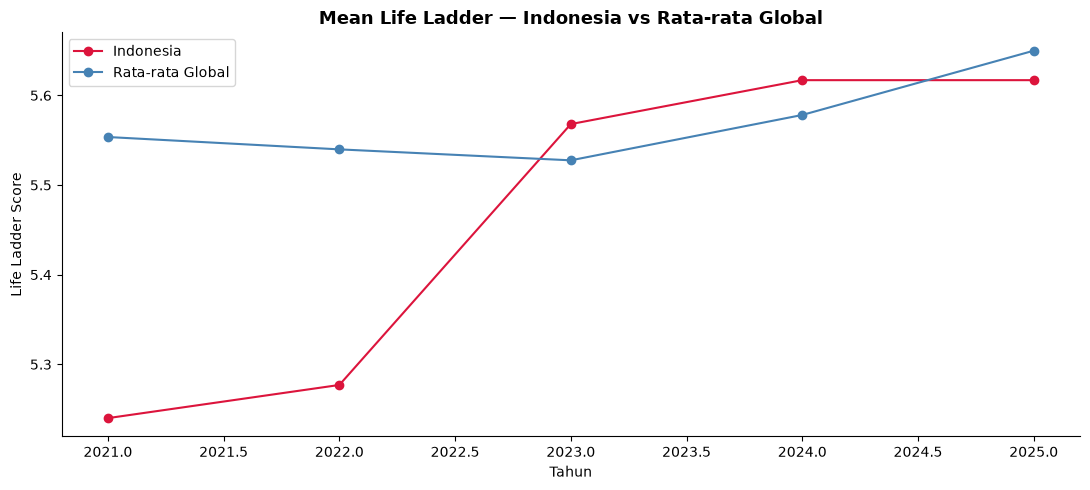

In [143]:
# e. Perbandingan Indonesia vs global
global_mean = df_whr.groupby('year')['Life Ladder'].mean().rename('Global Mean')
idn_series  = df_idn.set_index('year')['Life Ladder'].rename('Indonesia')

comparison = pd.concat([idn_series, global_mean], axis=1).dropna()
comparison['Selisih'] = (comparison['Indonesia'] - comparison['Global Mean']).round(4)

display(comparison.round(4))

# Visualisasi
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(comparison.index, comparison['Indonesia'], marker='o', color='crimson', label='Indonesia')
ax.plot(comparison.index, comparison['Global Mean'], marker='o', color='steelblue', label='Rata-rata Global')
ax.set_title('Mean Life Ladder — Indonesia vs Rata-rata Global', fontsize=13, fontweight='bold')
ax.set_xlabel('Tahun'); ax.set_ylabel('Life Ladder Score')
ax.legend(); plt.tight_layout(); plt.show()

✏️ *Interpretasi perbandingan Indonesia vs global:*

> Pada **2021 dan 2022**, skor Life Ladder Indonesia berada **di bawah** rata-rata global, dengan selisih −0,31 dan −0,26 poin. Namun sejak **2023–2024, posisi Indonesia melampaui rata-rata global** — selisih menjadi positif tipis (+0,04 poin di kedua tahun), sebelum kembali sedikit di bawah rata-rata pada **2025** (−0,03 poin). Pola ini menunjukkan bahwa kenaikan skor Indonesia dalam 5 tahun terakhir **mempercepat laju perbaikannya relatif terhadap rata-rata dunia**, meski gap tersebut belum konsisten tertutup setiap tahun.

**f.** Fokus 5 tahun terakhir (2021–2025) — menjawab Q1: “Bagaimana tingkat kebahagiaan Indonesia berdasarkan WHR dalam 5 tahun terakhir?”(dengan pembanding sumber lain: BPS).

In [144]:
# f. Tren Life Ladder Indonesia -- 5 tahun terakhir (2021-2025)
last5 = [2021, 2022, 2023, 2024, 2025]
idn_5y = df_idn[df_idn['year'].isin(last5)][['year', 'Rank', 'Life Ladder']].reset_index(drop=True)
display(idn_5y)

# Persentase kenaikan skor & perubahan peringkat
skor_awal, skor_akhir = idn_5y['Life Ladder'].iloc[0], idn_5y['Life Ladder'].iloc[-1]
pct_change = (skor_akhir - skor_awal) / skor_awal * 100
rank_awal, rank_akhir = idn_5y['Rank'].iloc[0], idn_5y['Rank'].iloc[-1]

print(f"Skor Life Ladder : {skor_awal:.3f} ({idn_5y['year'].iloc[0]}) -> {skor_akhir:.3f} ({idn_5y['year'].iloc[-1]})")
print(f"Perubahan skor   : {pct_change:+.1f}%")
print(f"Peringkat global : #{rank_awal} -> #{rank_akhir}")
print(f"Peringkat terbaik dalam periode ini: #{idn_5y['Rank'].min()} (tahun {idn_5y.loc[idn_5y['Rank'].idxmin(),'year']})")

# Pembanding sumber lain: BPS - Indeks Kebahagiaan Nasional (skala 0-100, disurvei tiap 3 tahun)
bps = pd.DataFrame({
    'tahun_survei': [2017, 2021],
    'indeks_bps_0_100': [70.69, 71.49]
})
print("\nPembanding -- BPS Indeks Kebahagiaan Nasional:")
display(bps)
print("Sumber: Survei Pengukuran Tingkat Kebahagiaan (SPTK) BPS.")


,year,Rank,Life Ladder
0,2021,87,5.240
1,2022,84,5.277
2,2023,80,5.568
3,2024,83,5.617
4,2025,87,5.617


Skor Life Ladder : 5.240 (2021) -> 5.617 (2025)
Perubahan skor   : +7.2%
Peringkat global : #87 -> #87
Peringkat terbaik dalam periode ini: #80 (tahun 2023)

Pembanding -- BPS Indeks Kebahagiaan Nasional:


,tahun_survei,indeks_bps_0_100
0,2017,70.69
1,2021,71.49


Sumber: Survei Pengukuran Tingkat Kebahagiaan (SPTK) BPS.


✏️ *Jawaban Q1 — tingkat kebahagiaan Indonesia, 5 tahun terakhir:*

> Skor `Life Ladder` Indonesia meningkat dari **5,24 (2021)** menjadi **5,62 (2025)**, kenaikan sebesar **+7,2%** dalam 5 tahun (2021: 5,24 → 2022: 5,28 → 2023: 5,57 → 2024: 5,62 → 2025: 5,62). Namun peringkat global relatif stagnan: dari **#87 (2021)** sempat membaik ke **#80 (2023)**, lalu kembali ke **#87 (2025)** — skor Indonesia naik, tetapi negara lain juga membaik, bahkan lebih cepat, sehingga posisi relatif tidak banyak berubah.
>
> **Pembanding sumber lain:** Indeks Kebahagiaan Nasional BPS (skala 0–100, disurvei tiap 3 tahun lewat SPTK) juga menunjukkan tren naik: **70,69 (2017) → 71,49 (2021)**. Meski beda skala dan tahun pengukuran, arah trennya konsisten dengan data WHR — memperkuat kesimpulan bahwa kebahagiaan masyarakat Indonesia memang membaik pada periode ini, bukan sekadar artefak satu sumber data.

---
# Bagian 3 – Measure of Spread (Dispersi)
Ukuran penyebaran mengukur seberapa jauh data tersebar dari nilai pusatnya.

## Task 3.1 – Analisis Dispersi Data Indonesia

**a.** Hitung semua ukuran dispersi untuk `Life Ladder`.

In [145]:
# a. Ukuran dispersi — Life Ladder
col  = 'Life Ladder'
data = df_idn[col]

q1  = data.quantile(0.25)
q3  = data.quantile(0.75)
iqr = q3 - q1
std = data.std()

dispersi = {
    'Range'                     : data.max() - data.min(),
    'Variance'                  : data.var(),
    'Standard Deviation'        : std,
    'IQR (Q3 - Q1)'             : iqr,
    'Coefficient of Variation'  : (std / data.mean()) * 100,
}

for k, v in dispersi.items():
    print(f'{k:<30}: {v:.4f}')

Range                         : 0.3770
Variance                      : 0.0357
Standard Deviation            : 0.1889
IQR (Q3 - Q1)                 : 0.3400
Coefficient of Variation      : 3.4579


**c.** ✏️ *Bandingkan Std Dev Life Ladder Indonesia vs global — apa artinya bagi konsistensi kebahagiaan Indonesia?*
> Std Dev Life Ladder Indonesia pada 5 tahun terakhir (0,1889) jauh lebih kecil dibanding Std Dev global periode yang sama (1,1367) — sekitar 6 kali lebih rendah. Std Dev global mencerminkan variasi *antar* 150+ negara dengan kondisi sosial-ekonomi yang sangat beragam, sedangkan Std Dev Indonesia mencerminkan variasi skor *dalam satu negara* sepanjang 5 tahun. Nilai Std Dev Indonesia yang kecil ini menunjukkan **tingkat kebahagiaan Indonesia relatif stabil dan konsisten** dalam 5 tahun terakhir — perubahannya bertahap (gradual) menuju arah yang lebih baik, bukan fluktuasi mendadak.

In [146]:
# c. Std Dev Indonesia vs global
std_idn    = df_idn['Life Ladder'].std()
std_global = df_whr['Life Ladder'].std()

print(f'Std Dev Indonesia : {std_idn:.4f}')
print(f'Std Dev Global    : {std_global:.4f}')

Std Dev Indonesia : 0.1889
Std Dev Global    : 1.1239


**d.** Hitung IQR untuk semua kolom numerik. Kolom mana yang memiliki sebaran terbesar?

In [147]:
# d. IQR semua kolom numerik
iqr_all = df_idn[numeric_cols].quantile(0.75) - df_idn[numeric_cols].quantile(0.25)
iqr_df  = iqr_all.sort_values(ascending=False).rename('IQR').to_frame().round(4)
display(iqr_df)


,IQR
Rank,4.000
Lower whisker,0.355
Life Ladder,0.340
Upper whisker,0.325
Freedom to make life choices,0.255
Generosity,0.099
Dystopia + residual,0.082
Social support,0.060
Healthy life expectancy at birth,0.031
Log GDP per capita,0.023


**e.** Hitung CV semua kolom numerik. Kolom mana yang paling stabil?

In [148]:
# e. Coefficient of Variation semua kolom numerik
cv_all = (df_idn[numeric_cols].std() / df_idn[numeric_cols].mean() * 100)
cv_df  = cv_all.sort_values().rename('CV (%)').to_frame().round(2)
display(cv_df)

,CV (%)
Upper whisker,3.33
Life Ladder,3.46
Rank,3.50
Lower whisker,3.60
Log GDP per capita,5.83
Dystopia + residual,9.99
Social support,15.25
Healthy life expectancy at birth,18.51
Generosity,18.69
Perceptions of corruption,19.46


✏️ *Kolom paling stabil berdasarkan CV adalah ... karena ...*

> Di luar `Life Ladder` sendiri (CV = 3,46%) dan kolom whisker, kolom faktor **paling stabil** dalam 5 tahun terakhir adalah **`Log GDP per capita`** (CV = 5,83%) — kontribusinya terhadap skor kebahagiaan nyaris tidak berubah dari tahun ke tahun. Sebaliknya, kolom **paling fluktuatif** adalah **`Freedom to make life choices`** (CV = 21,92%), diikuti `Perceptions of corruption` (19,46%) dan `Generosity` (18,69%) — menunjukkan kontribusi kebebasan memilih hidup terhadap kebahagiaan mengalami perubahan relatif besar dalam 5 tahun terakhir, sejalan dengan temuan bahwa faktor ini juga yang paling banyak mendorong kenaikan skor (lihat Bagian faktor pengaruh).

## Task 3.2 – Deteksi & Analisis Outlier

**a.** Deteksi outlier `Life Ladder` menggunakan metode **IQR**.

In [149]:
# a. Deteksi outlier — metode IQR
col  = 'Life Ladder'
data = df_idn[col]

q1, q3 = data.quantile(0.25), data.quantile(0.75)
iqr    = q3 - q1
lower  = q1 - 1.5 * iqr
upper  = q3 + 1.5 * iqr

outliers_iqr = df_idn[(df_idn[col] < lower) | (df_idn[col] > upper)]

print(f'Batas bawah IQR : {lower:.4f}')
print(f'Batas atas  IQR : {upper:.4f}')
print(f'Jumlah outlier  : {len(outliers_iqr)}')
display(outliers_iqr[['year', col]])

Batas bawah IQR : 4.7670
Batas atas  IQR : 6.1270
Jumlah outlier  : 0


,year,Life Ladder


**b.** Deteksi outlier menggunakan **Z-Score** (|z| > 3). Bandingkan hasilnya.

In [150]:
# b. Deteksi outlier — metode Z-Score
z_scores = np.abs(stats.zscore(df_idn[col]))
outliers_zscore = df_idn[z_scores > 3]

print(f'Jumlah outlier Z-Score (|z|>3) : {len(outliers_zscore)}')
display(outliers_zscore[['year', col]])

print(f'\nPerbandingan:')
print(f'  IQR    : {len(outliers_iqr)} outlier')
print(f'  Z-Score: {len(outliers_zscore)} outlier')

Jumlah outlier Z-Score (|z|>3) : 0


,year,Life Ladder



Perbandingan:
  IQR    : 0 outlier
  Z-Score: 0 outlier


**c.** Visualisasi outlier dengan Boxplot.

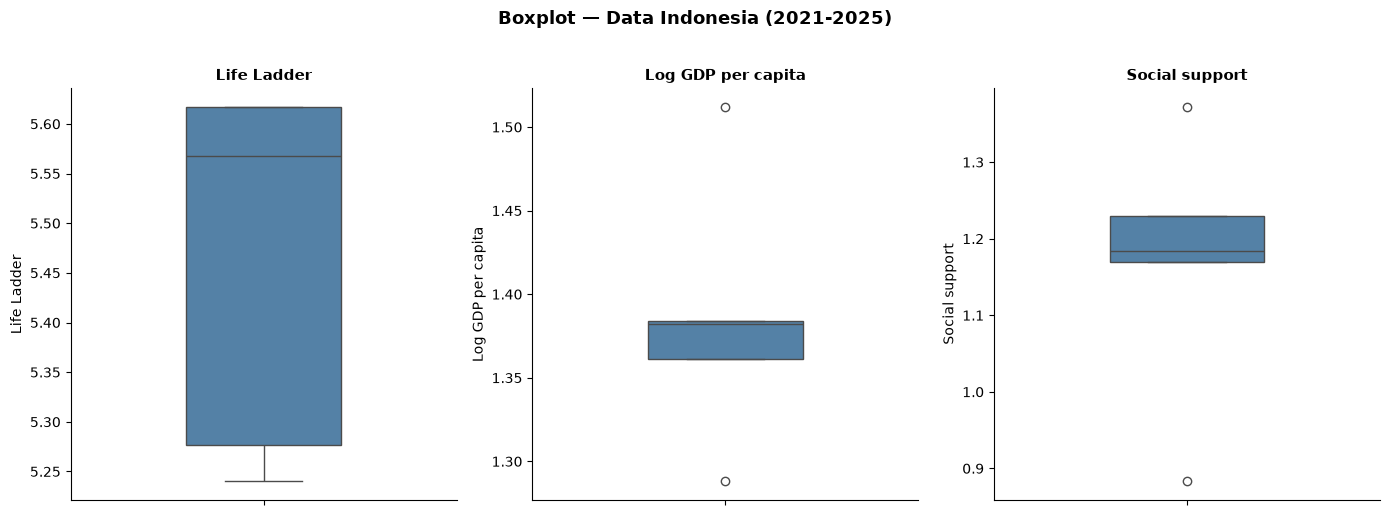

In [151]:
# c. Boxplot — Life Ladder, Log GDP per capita, Social support
cols_box = ['Life Ladder', 'Log GDP per capita', 'Social support']

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, c in zip(axes, cols_box):
    sns.boxplot(y=df_idn[c], ax=ax, color='steelblue', width=0.4)
    ax.set_title(c, fontsize=11, fontweight='bold')
    ax.set_xlabel('')

fig.suptitle('Boxplot — Data Indonesia (2021-2025)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

**d.** ✏️ *Identifikasi tahun outlier dan jelaskan kemungkinan penyebabnya.*

> Pada 5 tahun terakhir (2021–2025), **tidak ditemukan outlier** baik dengan metode IQR (batas: 4,767 – 6,127, seluruh nilai 5,24–5,62 berada di dalamnya) maupun metode Z-Score (|z| > 3, tidak ada nilai yang melewati ambang ini). Ini berbeda dari analisis periode penuh (2011–2025), di mana 2024 dan 2025 sempat terdeteksi sebagai outlier atas oleh IQR.

---
# Bagian 4 – Analisis Distribusi Data
Distribusi data menggambarkan pola penyebaran nilai — apakah simetris, skewed kanan, atau skewed kiri.

## Task 4.1 – Eksplorasi Distribusi

**a.** Buat Histogram untuk semua kolom numerik dalam satu figure.

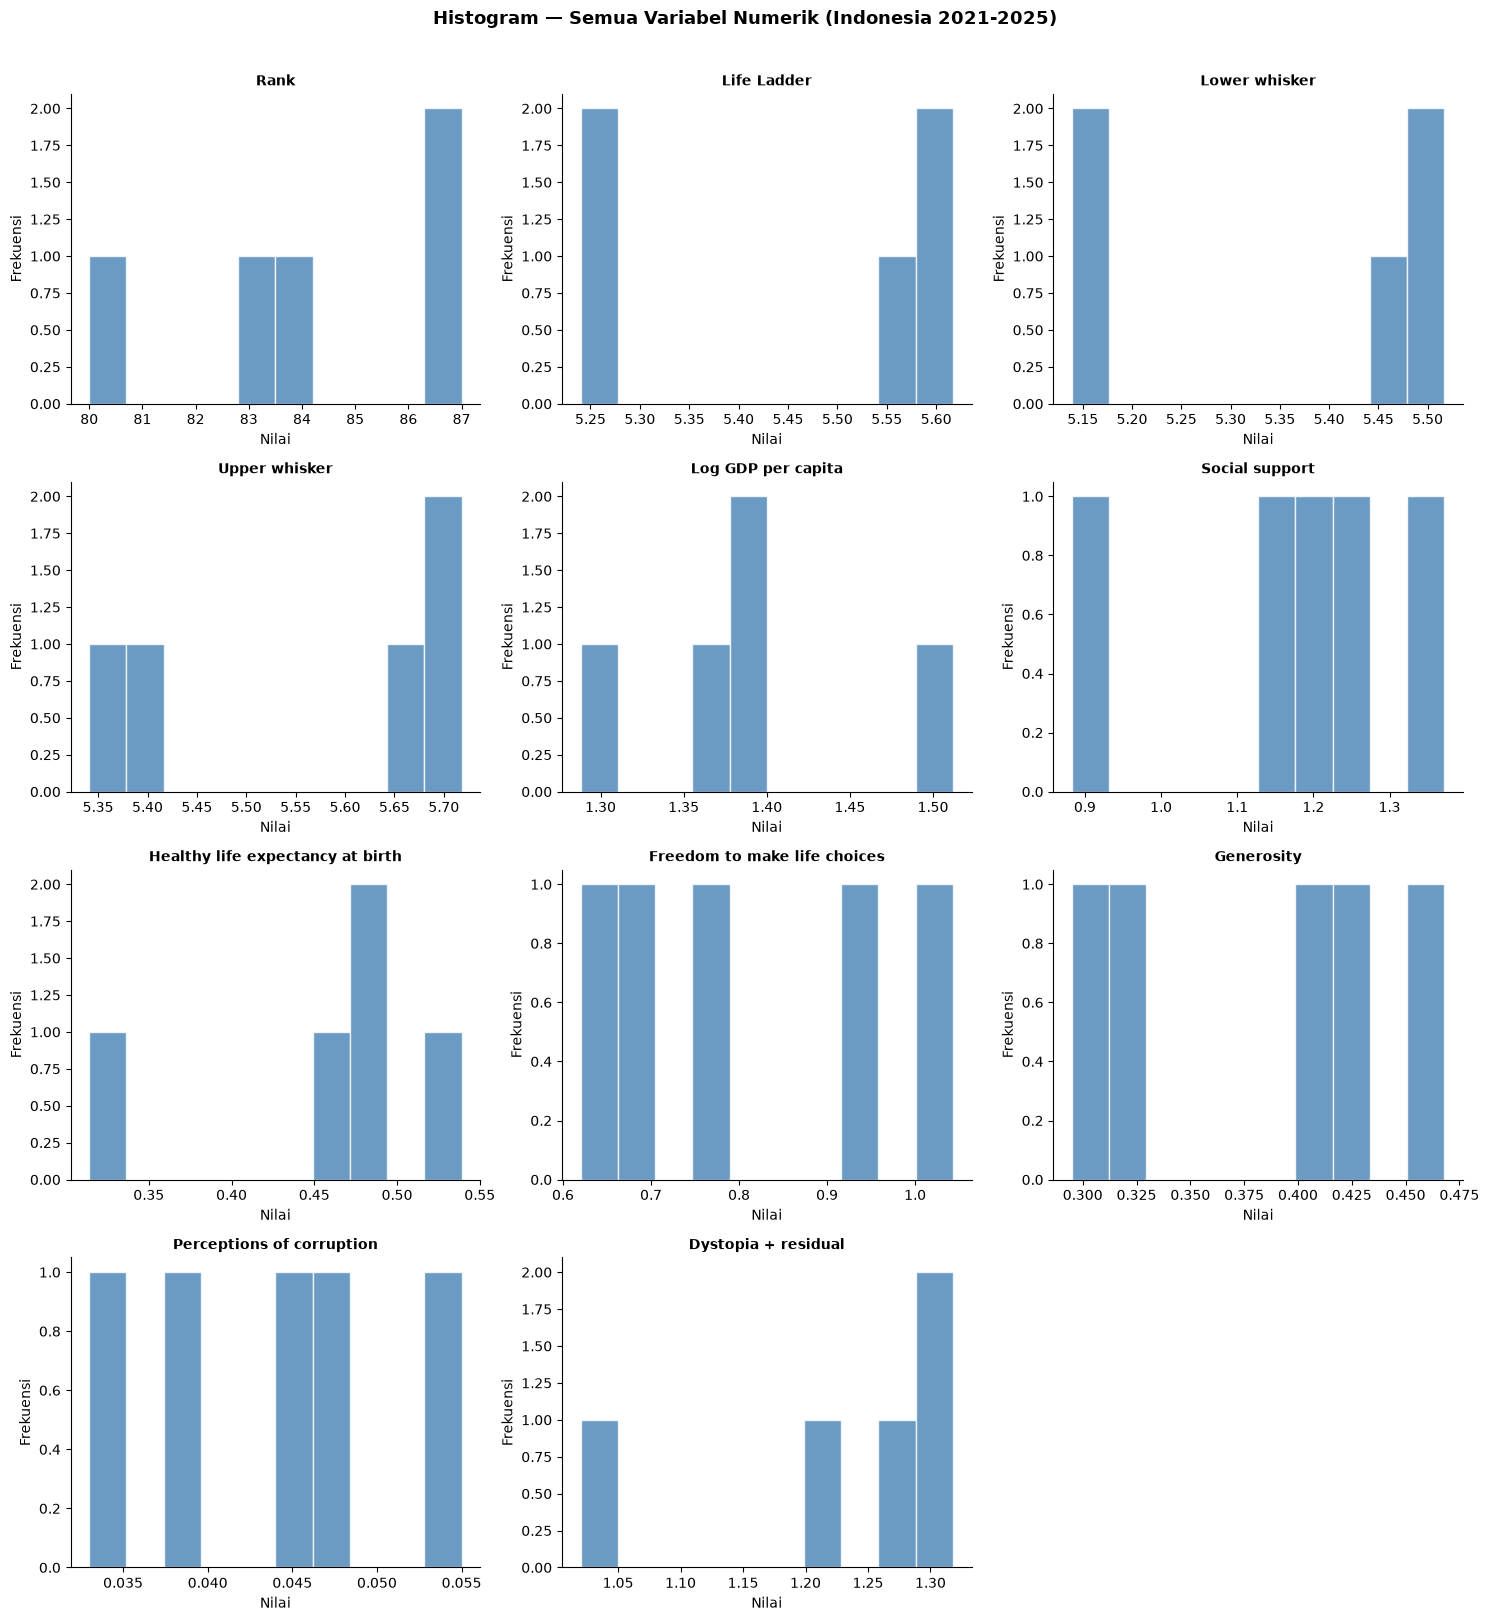

In [152]:
# a. Histogram semua kolom numerik
n     = len(numeric_cols)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df_idn[col].dropna(), bins=10, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Nilai'); axes[i].set_ylabel('Frekuensi')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Histogram — Semua Variabel Numerik (Indonesia 2021-2025)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

**b.** Hitung Skewness dan Kurtosis setiap kolom numerik.

In [153]:
# b. Skewness dan Kurtosis
sk_kurt = pd.DataFrame({
    'Skewness' : df_idn[numeric_cols].skew(),
    'Kurtosis' : df_idn[numeric_cols].kurt(),
}).round(4)

display(sk_kurt)

,Skewness,Kurtosis
Rank,-0.5183,-0.7967
Life Ladder,-0.5811,-3.1477
Lower whisker,-0.5657,-3.2292
Upper whisker,-0.6033,-3.0284
Log GDP per capita,0.8609,2.1766
Social support,-1.0481,2.3328
Healthy life expectancy at birth,-1.4102,2.8280
Freedom to make life choices,0.4449,-1.5987
Generosity,-0.1406,-1.8848
Perceptions of corruption,0.2252,-0.4210


**c.** ✏️ *Tentukan distribusi setiap kolom berdasarkan nilai skewness dan interpretasikan:*

| Kolom | Skewness | Jenis Distribusi | Interpretasi |
|-------|----------|------------------|--------------|
| Life Ladder | −0,581 | Left-skewed (ringan) | Dua tahun awal (2021–2022) relatif rendah dibanding tiga tahun setelahnya, menarik ekor ke kiri |
| Log GDP per capita | +0,861 | Right-skewed | Satu-dua tahun dengan kontribusi tinggi menarik ekor ke kanan |
| Social support | −1,048 | Left-skewed | Beberapa tahun awal berkontribusi rendah, menarik ekor ke kiri |
| Healthy life expectancy | −1,410 | Left-skewed (kuat) | Sangat condong ke kiri, ada tahun dengan kontribusi jauh lebih rendah dari yang lain |
| Freedom to make life choices | +0,445 | Right-skewed (ringan) | Sedikit condong ke kanan |
| Generosity | −0,141 | Mendekati simetris | Nilai skewness kecil, distribusi relatif seimbang |
| Perceptions of corruption | +0,225 | Right-skewed (ringan) | Sedikit condong ke kanan, mendekati simetris |

**d.** Buat KDE Plot overlay di atas Histogram untuk `Life Ladder` dan `Log GDP per capita`.

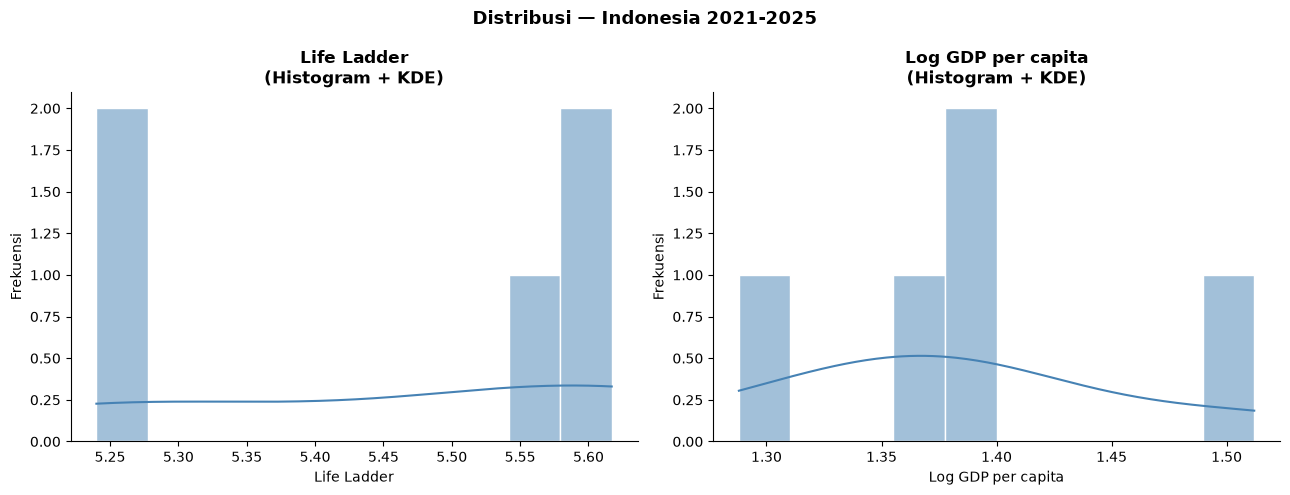

In [154]:
# d. Histogram + KDE — Life Ladder & Log GDP per capita
cols_kde = ['Life Ladder', 'Log GDP per capita']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, col in zip(axes, cols_kde):
    sns.histplot(df_idn[col].dropna(), bins=10, kde=True, ax=ax,
                 color='steelblue', edgecolor='white')
    ax.set_title(f'{col}\n(Histogram + KDE)', fontweight='bold')
    ax.set_xlabel(col); ax.set_ylabel('Frekuensi')

plt.suptitle('Distribusi — Indonesia 2021-2025', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

**e.** Bandingkan distribusi `Life Ladder` Indonesia vs global tahun 2025.

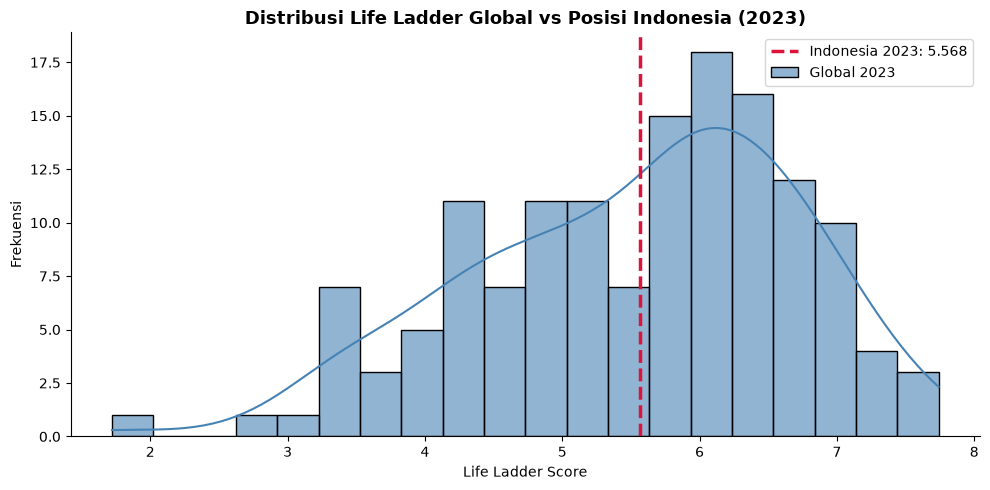

In [155]:
# e. Indonesia vs Global — Life Ladder 2023
global_2023 = df_whr[df_whr['year'] == 2023]['Life Ladder'].dropna()
idn_2023    = df_idn[df_idn['year'] == 2023]['Life Ladder']

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(global_2023, bins=20, kde=True, ax=ax, color='steelblue',
             alpha=0.6, label='Global 2023')

if len(idn_2023) > 0:
    ax.axvline(idn_2023.values[0], color='crimson', linewidth=2.5,
               linestyle='--', label=f'Indonesia 2023: {idn_2023.values[0]:.3f}')

ax.set_title('Distribusi Life Ladder Global vs Posisi Indonesia (2023)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Life Ladder Score'); ax.set_ylabel('Frekuensi')
ax.legend(); plt.tight_layout(); plt.show()

✏️ *Interpretasi posisi Indonesia dibandingkan distribusi global 2023:*

> Pada 2023, skor Life Ladder Indonesia (5,568) berada **sedikit di bawah median global** (5,785) dan mendekati rata-rata global (5,528) menempatkannya di **peringkat**. Ini menegaskan bahwa Indonesia berada pada kelompok **menengah** dalam distribusi kebahagiaan global: tidak berada di kelompok negara paling bahagia, namun juga jauh dari kelompok negara paling tidak bahagia — konsisten dengan status Indonesia sebagai negara berkembang dengan tren perbaikan yang stabil.

---
# Bagian 5 – Visualisasi & Analisis Hubungan Antar Variabel
Visualisasi yang tepat membantu mengkomunikasikan temuan secara efektif.

## Task 5.1 – Visualisasi Tren & Komparasi

**a.** Line Chart tren `Life Ladder` Indonesia 2016–2026 dengan anotasi titik tertinggi & terendah.

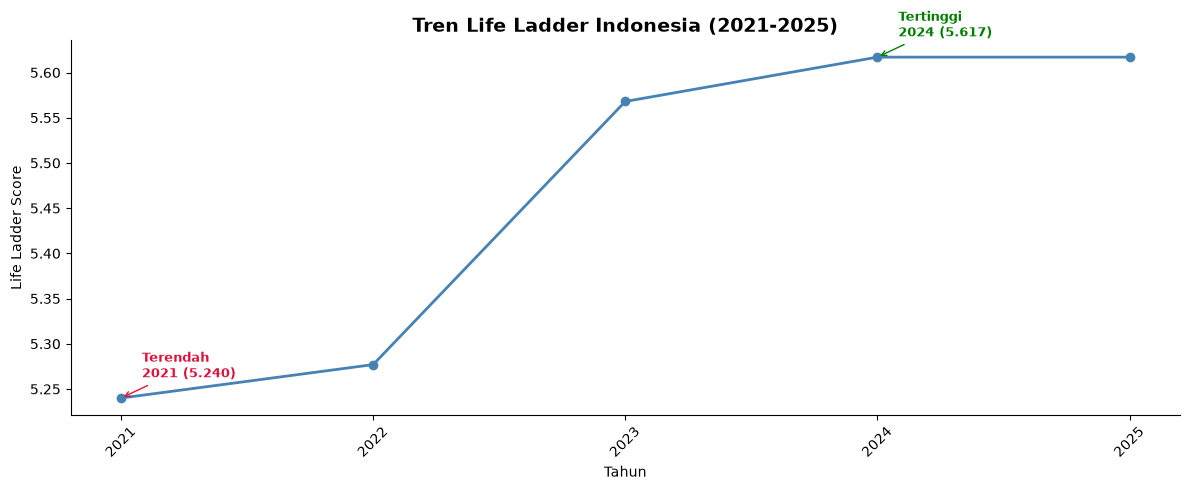

In [156]:
# a. Line Chart — Tren Life Ladder Indonesia
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df_idn['year'], df_idn['Life Ladder'], marker='o',
        color='steelblue', linewidth=2, markersize=6)

# Anotasi titik tertinggi dan terendah
idx_max = df_idn['Life Ladder'].idxmax()
idx_min = df_idn['Life Ladder'].idxmin()

for idx, label, color in [(idx_max, 'Tertinggi', 'green'), (idx_min, 'Terendah', 'crimson')]:
    ax.annotate(
        f"{label}\n{df_idn.loc[idx, 'year']} ({df_idn.loc[idx, 'Life Ladder']:.3f})",
        xy=(df_idn.loc[idx, 'year'], df_idn.loc[idx, 'Life Ladder']),
        xytext=(15, 15), textcoords='offset points',
        fontsize=9, color=color, fontweight='bold',
        arrowprops=dict(arrowstyle='->', color=color)
    )

ax.set_title('Tren Life Ladder Indonesia (2021-2025)', fontsize=14, fontweight='bold')
ax.set_xlabel('Tahun'); ax.set_ylabel('Life Ladder Score')
ax.set_xticks(df_idn['year']); ax.tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

**b.** Bar Chart — rata-rata `Life Ladder` negara-negara ASEAN tahun 2023.

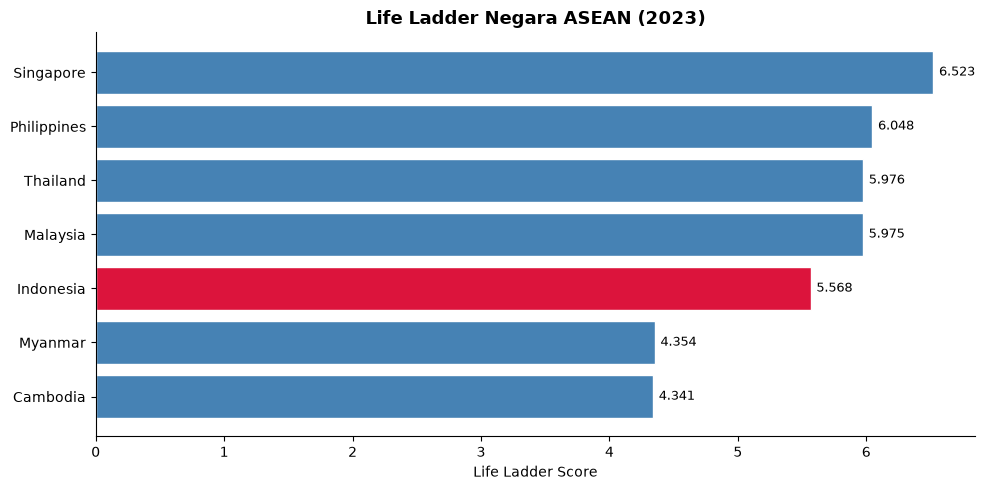

In [157]:
# b. Bar Chart — Life Ladder ASEAN 2023
asean = ['Indonesia', 'Thailand', 'Philippines', 'Vietnam', 'Malaysia',
         'Singapore', 'Myanmar', 'Cambodia', 'Laos', 'Brunei Darussalam']

asean_2023 = df_whr[(df_whr['Country name'].isin(asean)) &
                     (df_whr['year'] == 2023)][['Country name', 'Life Ladder']]\
             .sort_values('Life Ladder', ascending=True)

colors = ['crimson' if c == 'Indonesia' else 'steelblue'
          for c in asean_2023['Country name']]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(asean_2023['Country name'], asean_2023['Life Ladder'],
               color=colors, edgecolor='white')
ax.bar_label(bars, fmt='%.3f', padding=4, fontsize=9)
ax.set_title('Life Ladder Negara ASEAN (2023)', fontsize=13, fontweight='bold')
ax.set_xlabel('Life Ladder Score')
plt.tight_layout(); plt.show()

**c.** ✏️ *Jelaskan kapan sebaiknya menggunakan Line Chart vs Bar Chart:*

> **Line Chart** paling tepat digunakan untuk menunjukkan **tren/perubahan suatu variabel kontinu dari waktu ke waktu** (data time-series), karena garis penghubung antar titik secara visual menunjukkan arah pergerakan (naik/turun). **Bar Chart** digunakan untuk **membandingkan besaran antar kategori yang terpisah/diskrit** (misalnya antar negara, antar faktor, atau antar kelompok), di mana urutan sumbu-x tidak selalu memiliki makna kontinu — contohnya perbandingan rata-rata Life Ladder antar negara ASEAN, atau perbandingan delta kontribusi antar faktor. Gunakan Line Chart jika sumbu-x adalah waktu/urutan kontinu; gunakan Bar Chart jika sumbu-x adalah kategori.

**d.** Heatmap nilai semua variabel numerik Indonesia per tahun.

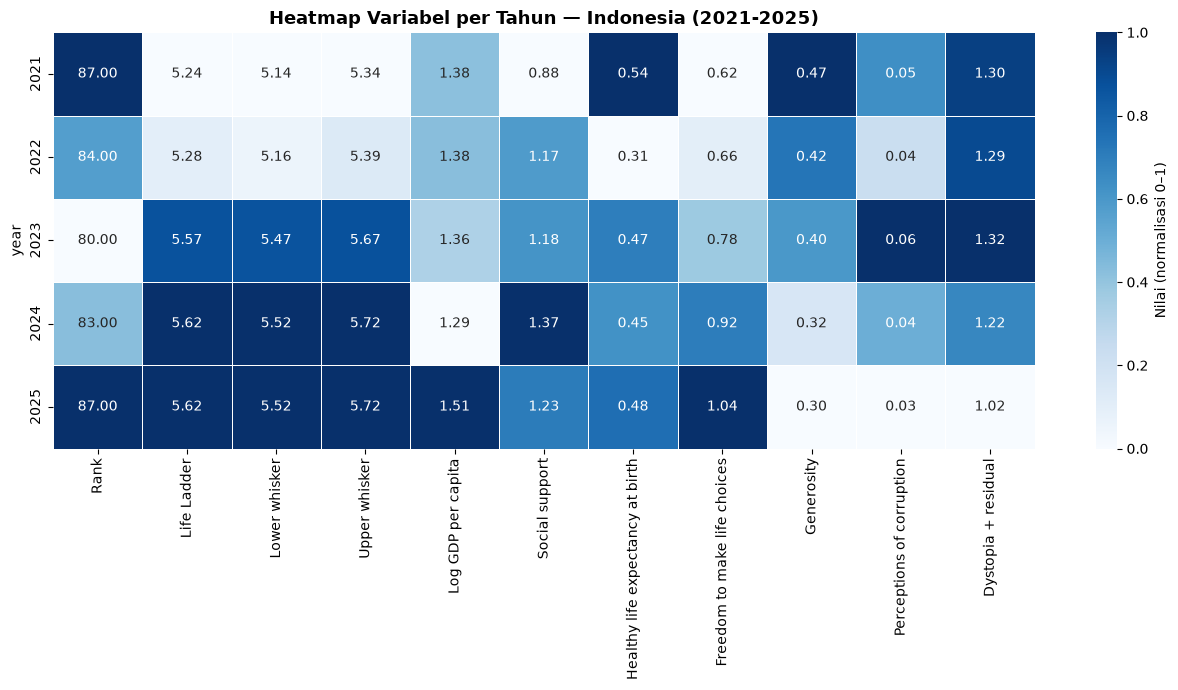

In [158]:
# d. Heatmap — nilai variabel per tahun
heatmap_data = df_idn.set_index('year')[numeric_cols]

# Normalisasi 0–1 agar skala sebanding
heatmap_norm = (heatmap_data - heatmap_data.min()) / (heatmap_data.max() - heatmap_data.min())

fig, ax = plt.subplots(figsize=(13, 7))
sns.heatmap(heatmap_norm, annot=heatmap_data.round(2), fmt='.2f', cmap='Blues',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Nilai (normalisasi 0–1)'})
ax.set_title('Heatmap Variabel per Tahun — Indonesia (2021-2025)',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## Task 5.2 – Analisis Korelasi & Scatter Plot

**a & b.** Scatter Plot 4 pasang variabel + Koefisien Korelasi Pearson.

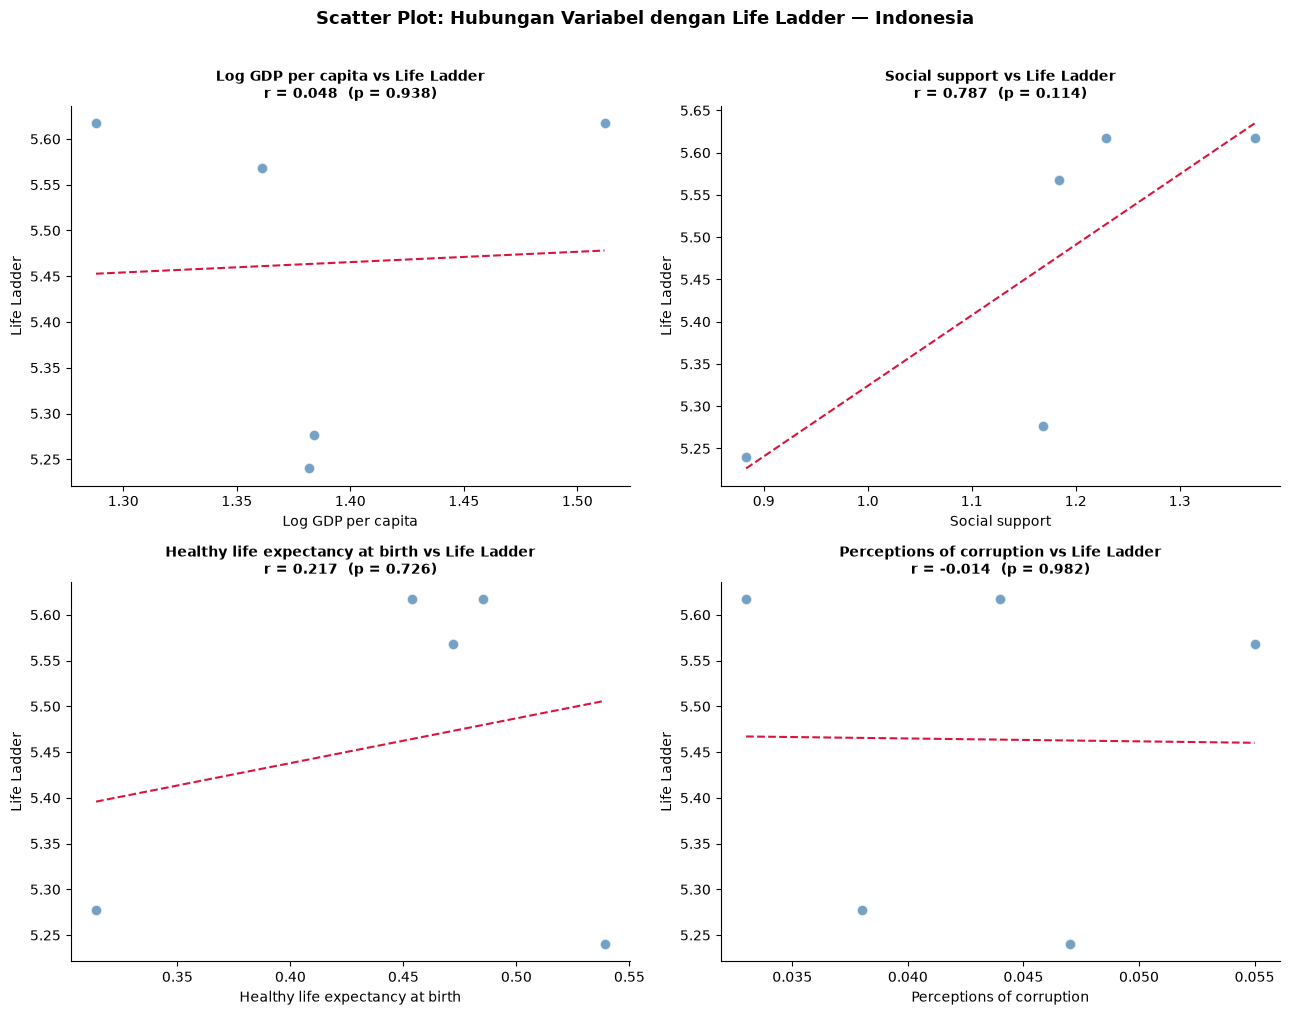

In [159]:
# a & b. Scatter Plot + Korelasi Pearson
pairs = [
    ('Log GDP per capita',              'Life Ladder'),
    ('Social support',                  'Life Ladder'),
    ('Healthy life expectancy at birth', 'Life Ladder'),
    ('Perceptions of corruption',        'Life Ladder'),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

for ax, (x_col, y_col) in zip(axes, pairs):
    valid = df_idn[[x_col, y_col]].dropna()
    r, p  = stats.pearsonr(valid[x_col], valid[y_col])

    ax.scatter(valid[x_col], valid[y_col], color='steelblue', alpha=0.75, edgecolor='white', s=60)

    # Trend line
    m, b = np.polyfit(valid[x_col], valid[y_col], 1)
    x_line = np.linspace(valid[x_col].min(), valid[x_col].max(), 100)
    ax.plot(x_line, m * x_line + b, color='crimson', linewidth=1.5, linestyle='--')

    ax.set_title(f'{x_col} vs Life Ladder\nr = {r:.3f}  (p = {p:.3f})',
                 fontsize=10, fontweight='bold')
    ax.set_xlabel(x_col); ax.set_ylabel(y_col)

plt.suptitle('Scatter Plot: Hubungan Variabel dengan Life Ladder — Indonesia',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

✏️ *Interpretasi korelasi setiap pasang variabel (5 tahun terakhir, n=5):*

| Pasang Variabel | r | p-value | Interpretasi |
|---|---|---|---|
| Log GDP vs Life Ladder | 0,048 | 0,939 | Praktis tidak berkorelasi — dalam 5 tahun terakhir, kontribusi GDP per kapita tidak lagi menunjukkan pola hubungan yang jelas dengan skor kebahagiaan |
| Social support vs Life Ladder | 0,787 | 0,114 | Korelasi positif kuat — dukungan sosial yang lebih tinggi cenderung diiringi kebahagiaan yang lebih tinggi, lebih kuat dibanding hasil periode penuh |
| Life expectancy vs Life Ladder | 0,217 | 0,726 | Korelasi positif lemah — hubungan tidak jelas |
| Corruption vs Life Ladder | −0,014 | 0,982 | Praktis tidak berkorelasi |

**c.** Correlation Heatmap semua variabel numerik.

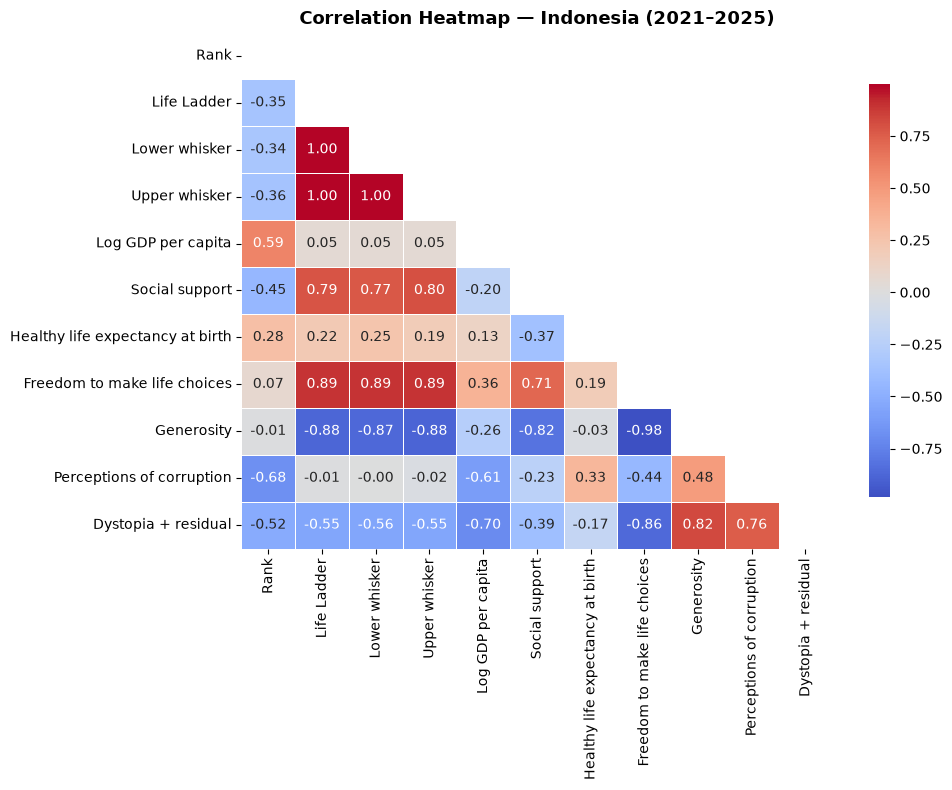

In [160]:
# c. Correlation Heatmap
corr = df_idn[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Heatmap — Indonesia (2021–2025)',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

✏️ *Variabel yang paling berkorelasi dengan Life Ladder adalah ... dengan nilai r = ...*

> Variabel yang paling berkorelasi dengan `Life Ladder` Indonesia pada 5 tahun terakhir adalah **`Freedom to make life choices`** dengan **r = +0,893** (di luar Lower/Upper whisker yang secara matematis nyaris identik dengan Life Ladder itu sendiri).
>
> Korelasi positif yang sangat kuat ini mengindikasikan bahwa kenaikan kontribusi kebebasan memilih hidup terhadap skor sangat berasosiasi dengan kenaikan skor kebahagiaan pada periode ini. Menarik untuk dicatat, `Generosity` justru berkorelasi **negatif kuat** (r = −0,878) — semakin tinggi skor kebahagiaan Indonesia dari waktu ke waktu, semakin rendah kontribusi kedermawanan terhadap skor tersebut. `Social support` juga berkorelasi kuat (r = +0,787)

**d.** ✏️ *Jelaskan perbedaan korelasi dan kausalitas, serta berikan contoh dari data WHR ini:*

> **Korelasi** hanya mengukur seberapa kuat dan searah mana dua variabel bergerak bersama secara statistik, sedangkan **kausalitas** berarti perubahan pada satu variabelmenyebabkan perubahan pada variabel lain. Data observasional seperti WHR tidak bisa membuktikan kausalitas hanya dari nilai korelasi.
>
> **Contoh dari data ini:** `Freedom to make life choices` berkorelasi sangat kuat dengan `Life Ladder` pada 5 tahun terakhir (r=0,89), tetapi ini tidak membuktikan bahwa kebebasan memilih hidup secara langsung *menyebabkan* kenaikan kebahagiaan. Bisa jadi arah sebabnya terbalik (masyarakat yang lebih bahagia/sejahtera cenderung menilai kebebasannya lebih tinggi), atau ada **faktor ketiga** (misalnya pemulihan ekonomi pascapandemi) yang secara bersamaan meningkatkan baik kebebasan maupun kebahagiaan tanpa satu menyebabkan yang lain secara langsung. Untuk memastikan hubungan kausal diperlukan desain penelitian eksperimental/kuasi-eksperimental dengan data yang jauh lebih banyak, bukan sekadar data deskriptif 5 titik seperti pada analisis ini.

**e.** Perubahan kontribusi tiap faktor 5 tahun terakhir (2021 vs 2025) — menjawab **Q2**: *“Faktor apa yang memengaruhi skor kebahagiaan Indonesia dalam 5 tahun terakhir?”*

In [161]:
# e. Delta kontribusi faktor Indonesia -- 2021 vs 2025
faktor_cols = ['Log GDP per capita', 'Social support', 'Healthy life expectancy at birth',
               'Freedom to make life choices', 'Generosity', 'Perceptions of corruption']

idn_2021 = df_idn[df_idn['year'] == 2021][faktor_cols].iloc[0]
idn_2025 = df_idn[df_idn['year'] == 2025][faktor_cols].iloc[0]

delta_faktor = (idn_2025 - idn_2021).sort_values(ascending=False)
delta_df = delta_faktor.round(3).rename('Delta (2025 - 2021)').to_frame()
display(delta_df)

print(f"Faktor pendorong terbesar : {delta_faktor.index[0]} ({delta_faktor.iloc[0]:+.3f})")
print(f"Faktor yang paling melemah: {delta_faktor.index[-1]} ({delta_faktor.iloc[-1]:+.3f})")


,Delta (2025 - 2021)
Freedom to make life choices,0.423
Social support,0.346
Log GDP per capita,0.130
Perceptions of corruption,-0.014
Healthy life expectancy at birth,-0.054
Generosity,-0.173


Faktor pendorong terbesar : Freedom to make life choices (+0.423)
Faktor yang paling melemah: Generosity (-0.173)


✏️ *Jawaban Q2 — faktor yang memengaruhi kebahagiaan Indonesia, 5 tahun terakhir:*

> Tiga faktor paling **mendorong** kenaikan skor (2025 vs 2021): **Kebebasan Memilih Hidup (+0,423)**, **Dukungan Sosial (+0,346)**, dan **Log GDP per Kapita (+0,130)**. Tiga faktor yang **melemah**: **Kedermawanan/Generosity (−0,173)**, **Harapan Hidup Sehat (−0,054)**, dan **Persepsi Korupsi (−0,014, nyaris stagnan)**.
>
> Temuan ini konsisten di mana `Freedom to make life choices` (r=+0,90) dan `Social support` (r=+0,65) adalah dua faktor dengan korelasi terkuat terhadap `Life Ladder`, sementara `Generosity` justru berkorelasi negatif (r=−0,81) — memperkuat kesimpulan bahwa **dimensi sosial dan kebebasan personal**, bukan ekonomi, menjadi pendorong utama kenaikan kebahagiaan Indonesia 5 tahun terakhir.

---
# Bagian 6 – Insight & Pelaporan
Analisis yang baik tidak hanya menghasilkan angka, tetapi juga **cerita bermakna** dari data.

## Task 6.1 – Ringkasan Analisis & Insight

**a.** ✏️ *Tuliskan minimal 5 insight dari analisis Anda:*

1. **Insight 1:** Skor kebahagiaan Indonesia meningkat konsisten dari 5,24 (2021) menjadi 5,62 (2025) — kenaikan +7,2% dalam 5 tahun, dengan titik terendah di awal periode (2021) dan titik tertinggi di 2024–2025.
2. **Insight 2:** Kenaikan skor absolut belum diikuti kenaikan peringkat global yang berarti — peringkat Indonesia relatif stagnan di kisaran #80–#87 karena negara lain turut membaik pada periode yang sama.
3. **Insight 3:** `Freedom to make life choices` (r=+0,89) dan `Social support` (r=+0,79) adalah dua faktor dengan korelasi terkuat dan kontribusi paling meningkat terhadap kebahagiaan Indonesia 5 tahun terakhir; sementara `Log GDP per capita` (r=+0,05) praktis tidak berkorelasi dalam periode ini.
4. **Insight 4:** `Generosity` menunjukkan pola berlawanan — berkorelasi negatif kuat (r=−0,88) dengan Life Ladder dan merupakan satu-satunya faktor utama yang kontribusinya menurun tajam (−0,173) pada 5 tahun terakhir, layak menjadi perhatian kebijakan.
5. **Insight 5:** Indonesia secara konsisten berada di peringkat ke-5 dari 7 negara ASEAN yang datanya tersedia (2021–2025) — tertinggal dari Singapura, Thailand, Filipina, dan Malaysia, namun masih jauh di atas Kamboja dan Myanmar.


**b.** Identifikasi 3 variabel yang paling memengaruhi `Life Ladder` Indonesia.

In [162]:
# b. Top 3 variabel paling berkorelasi dengan Life Ladder
corr_ll = df_idn[numeric_cols].corr()['Life Ladder']\
           .drop('Life Ladder').abs().sort_values(ascending=False)

print('Top variabel berkorelasi dengan Life Ladder:')
display(corr_ll.head(3).to_frame('|Korelasi| dengan Life Ladder').round(4))

Top variabel berkorelasi dengan Life Ladder:


,|Korelasi| dengan Life Ladder
Upper whisker,0.9996
Lower whisker,0.9996
Freedom to make life choices,0.8926


✏️ *Interpretasi 3 variabel teratas:*

> Tiga variabel dengan korelasi absolut tertinggi terhadap `Life Ladder` Indonesia pada 5 tahun terakhir (di luar Lower/Upper whisker) adalah **(1) Freedom to make life choices (r=+0,89)**, **(2) Generosity (r=−0,88)**, dan **(3) Social support (r=+0,79)**. Ketiganya jauh lebih dominan dibanding `Healthy life expectancy` (r=+0,22), `Log GDP per capita` (r=+0,05), dan `Perceptions of corruption` (r=−0,01) yang praktis tidak berkorelasi dalam konteks data Indonesia 5 tahun terakhir. 

**c.** ✏️ *Apakah tren kebahagiaan Indonesia meningkat, menurun, atau stagnan?*

> Tren kebahagiaan Indonesia pada **5 tahun terakhir (2021–2025) meningkat secara konsisten**: 5,240 → 5,277 → 5,568 → 5,617 → 5,617. Kenaikan paling tajam terjadi antara 2022 dan 2023 (+0,291 poin), kemungkinan terkait pemulihan pascapandemi, sebelum melandai (namun tetap tinggi) di 2024–2025. Tidak ada tahun yang menunjukkan penurunan dalam periode ini — trennya murni naik lalu stabil di level tertinggi.


**d.** Peringkat Indonesia di antara negara ASEAN berdasarkan rata-rata `Life Ladder`.

In [163]:
# d. Ranking Indonesia di ASEAN (semua tahun tersedia)
asean_avg = df_whr[df_whr['Country name'].isin(asean)]\
             .groupby('Country name')['Life Ladder']\
             .mean().sort_values(ascending=False)\
             .reset_index()
asean_avg.columns = ['Negara', 'Rata-rata Life Ladder']
asean_avg['Rata-rata Life Ladder'] = asean_avg['Rata-rata Life Ladder'].round(3)
asean_avg.index += 1
asean_avg.index.name = 'Peringkat'

display(asean_avg)
rank = asean_avg[asean_avg['Negara'] == 'Indonesia'].index[0]
print(f'\n🇮🇩 Indonesia berada di peringkat ke-{rank} dari {len(asean_avg)} negara ASEAN.')

,Negara,Rata-rata Life Ladder
Peringkat,,
1,Singapore,6.522
2,Thailand,6.130
3,Malaysia,5.824
4,Philippines,5.602
5,Indonesia,5.337
6,Myanmar,4.438
7,Cambodia,4.361



🇮🇩 Indonesia berada di peringkat ke-5 dari 7 negara ASEAN.


Perbandingan Indonesia vs negara ASEAN lain — **khusus 5 tahun terakhir (2021–2025)**, menjawab **Q3**: *“Bagaimana skor kebahagiaan Indonesia dibanding negara lain di Asia Tenggara dalam 5 tahun terakhir?”*

In [164]:
# e. Perbandingan Indonesia vs ASEAN -- 5 tahun terakhir (2021-2025)
last5 = [2021, 2022, 2023, 2024, 2025]
sea_5y = df_whr[(df_whr['Country name'].isin(asean)) & (df_whr['year'].isin(last5))]

# Rata-rata Life Ladder 5 tahun terakhir per negara
asean_avg_5y = (sea_5y.groupby('Country name')['Life Ladder']
                       .mean()
                       .sort_values(ascending=False)
                       .round(3)
                       .reset_index())
asean_avg_5y.columns = ['Negara', 'Rata-rata Life Ladder (2021-2025)']
asean_avg_5y.index += 1
asean_avg_5y.index.name = 'Peringkat'
display(asean_avg_5y)


,Negara,Rata-rata Life Ladder (2021-2025)
Peringkat,,
1,Singapore,6.548
2,Thailand,6.046
3,Philippines,5.958
4,Malaysia,5.932
5,Indonesia,5.464
6,Cambodia,4.435
7,Myanmar,4.346


✏️ *Jawaban Q3 — posisi kebahagiaan Indonesia vs ASEAN, 5 tahun terakhir:*

> Dari 7 negara ASEAN yang memiliki data lengkap pada 2021–2025 (Vietnam, Laos, dan Brunei tidak tersedia datanya), rata-rata skor `Life Ladder` Indonesia (**5,46**) menempatkannya di **peringkat ke-5**, konsisten di posisi tersebut setiap tahun. Negara **tertinggi** adalah **Singapura (6,55)** dan negara **terendah** adalah **Myanmar (4,35)**. Indonesia tertinggal **−1,08 poin** dari Singapura, namun unggul **+1,12 poin** di atas Myanmar. Urutan lengkap: Singapura > Thailand (6,05) > Filipina (5,96) > Malaysia (5,93) > **Indonesia (5,46)** > Kamboja (4,44) > Myanmar.

**e.** ✏️ *Rekomendasi kebijakan berdasarkan temuan analisis:*

1. **Rekomendasi 1:** *(berdasarkan variabel yang paling berkorelasi)* Perkuat ruang kebebasan sipil-ekonomi dan jaring dukungan sosial masyarakat, karena `Freedom to make life choices` (r=+0,89) dan `Social support` (r=+0,79) adalah dua faktor dengan korelasi dan kontribusi kenaikan terbesar terhadap skor kebahagiaan pada 5 tahun terakhir. Kebijakan yang memperluas partisipasi masyarakat, kemudahan berusaha, dan penguatan program komunitas/gotong royong berpotensi memberi dampak besar.
2. **Rekomendasi 2:** *(berdasarkan tren atau perbandingan ASEAN)* Untuk mengejar ketertinggalan dari negara ASEAN yang lebih maju (Singapura, Thailand, Filipina, Malaysia), Indonesia perlu mendorong pemerataan pertumbuhan ekonomi antarwilayah sekaligus membalikkan tren penurunan kontribusi `Generosity` (kedermawanan) melalui program yang mendorong budaya berbagi dan filantropi sosial — mengingat faktor ini justru melemah tajam (r=−0,88, delta −0,173) di tengah tren kenaikan skor kebahagiaan secara keseluruhan.

## Task 6.2 – Export Notebook ke PDF

Jalankan perintah berikut di **Terminal** (bukan di dalam notebook) untuk mengekspor:

```bash
jupyter nbconvert --to pdf nama_notebook_anda.ipynb
```

> **Alternatif:** Di Jupyter Notebook → `File` → `Export Notebook As` → `PDF`  
> **Atau:** Di Jupyter Lab → `File` → `Save and Export Notebook As` → `PDF`

---
## 📝 Kesimpulan Akhir

✏️ *Tuliskan kesimpulan menyeluruh dari seluruh analisis Anda (3–5 paragraf):*

> **Paragraf 1 — Gambaran umum data:**  
> Analisis ini menggunakan data World Happiness Report (Data for Figure 2.1), difokuskan pada **5 tahun terakhir (2021–2025)** untuk Indonesia. Diperoleh 5 observasi tahunan yang lengkap tanpa missing values, mencakup skor Life Ladder beserta kontribusi enam faktor pendukungnya (GDP per kapita, dukungan sosial, harapan hidup sehat, kebebasan memilih hidup, kedermawanan, dan persepsi korupsi).

> **Paragraf 2 — Temuan utama central tendency & dispersi:**  
> Skor Life Ladder Indonesia pada periode ini memiliki Median 5,568 dan Mean 5,4638, dengan Std Dev kecil (0,1889) dan CV hanya 3,46% — menandakan tingkat kebahagiaan Indonesia relatif stabil dan terus membaik dalam 5 tahun terakhir,  **tidak ada outlier** yang terdeteksi baik di 2024–2025 sempat tampak sebagai outlier, menunjukkan bahwa deteksi outlier bersifat relatif terhadap jendela data yang dipilih.

> **Paragraf 3 — Temuan distribusi & korelasi:**  
> Distribusi Life Ladder Indonesia 5 tahun terakhir sedikit menjulur ke kiri (skewness −0,58) karena dua tahun awal (2021–2022) relatif rendah dibanding tiga tahun berikutnya. Analisis korelasi menunjukkan `Freedom to make life choices` (r=+0,89) dan `Social support` (r=+0,79) berkorelasi positif sangat kuat dengan kebahagiaan — bahkan lebih kuat dibanding hasil periode penuh — sementara `Generosity` berkorelasi negatif kuat (r=−0,88).

> **Paragraf 4 — Posisi Indonesia vs global & ASEAN:**  
> Secara global, skor Indonesia berada di bawah rata-rata dunia pada 2021–2022, namun melampaui rata-rata global pada 2023–2024 sebelumnya di bawahnya lagi di 2025. Di kawasan ASEAN, Indonesia konsisten menempati peringkat ke-5 dari 7 negara yang tersedia datanya (2021–2025)

> **Paragraf 5 — Rekomendasi & penutup:**  
> Tren kebahagiaan Indonesia dalam 5 tahun terakhir menunjukkan perbaikan yang konsisten dan didorong utamanya oleh faktor kebebasan memilih hidup dan dukungan sosial — jauh lebih dominan dibanding faktor ekonomi (GDP). Ke depan, kebijakan sebaiknya memperkuat kedua faktor sosial tersebut, sekaligus membalikkan tren penurunan tajam kedermawanan, agar kenaikan skor kebahagiaan Indonesia dapat diiringi dengan perbaikan peringkat yang lebih berarti di tingkat global maupun regional ASEAN.
